## Corrupted analysis - makes no sense! Wow. Im stupid!

In [1]:
# Cell 1: Corrupt the SVA datasets by randomly swapping src_label and base_label
import json
import os
import random
from pathlib import Path

# Paths
input_dir = Path("datasets/final_datasets")
output_dir = Path("datasets/corrupted_cs_datasets_ver2")
output_dir.mkdir(parents=True, exist_ok=True)

# Splits to process
splits = ["train", "validation", "test"]

for split in splits:
    infile = input_dir / f"spanish_{split}_sva_dataset.json"
    outfile = output_dir / f"spanish_{split}_sva_dataset.json"
    
    # Load original data
    with open(infile, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Corrupt labels with 50% probability
    for item in data.values():
        if random.random() < 0.5:
            item["src_label"], item["base_label"] = item["base_label"], item["src_label"]
    
    # Write out corrupted dataset
    with open(outfile, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

print("Corrupted datasets saved to:", output_dir)

Corrupted datasets saved to: datasets/corrupted_cs_datasets_ver2


In [6]:
import os
import numpy as np
from sklearn.decomposition import PCA
from plotly.subplots import make_subplots
import plotly.graph_objs as go
from transformer_lens import HookedTransformer, utils
from load_dataset import load_sva_dataset

# 1) Setup
layer, head = 13, 7
hook_name = f"blocks.{layer}.attn.hook_result"
splits = ["train", "validation", "test"]
corrupt_path = "datasets/corrupted_cs_datasets_ver2"  # where cell 1 put your JSONs

# 2) Load model
model = HookedTransformer.from_pretrained("gemma-2b")
model.set_use_attn_result(True)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer


138
118
128
128
127
129
138
118
128
128
127
129


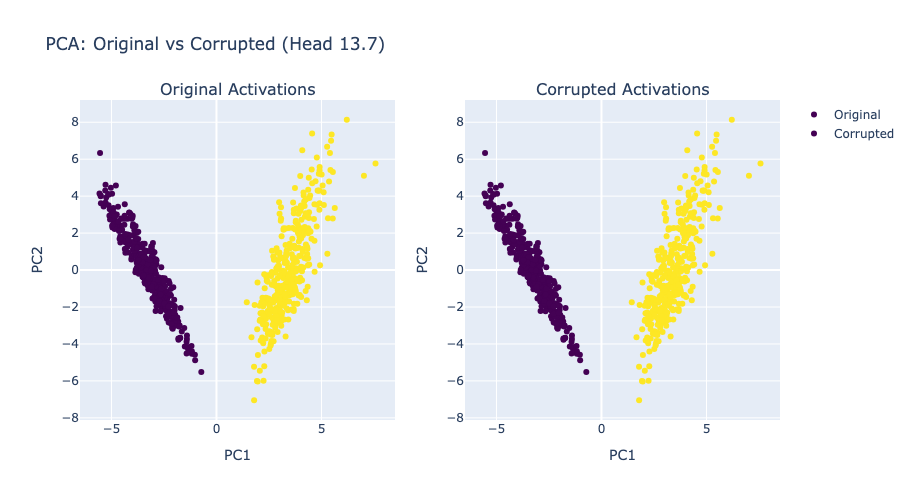

In [8]:
# 3) Gather ORIGINAL activations + labels + texts
orig_acts, orig_labels, orig_texts = [], [], []
for split in splits:
    ds = load_sva_dataset(model, "spanish", "both", split=split, num_samples=256)
    a, labs, txts = get_attn_activations(model, ds, hook_name, head)
    orig_acts.append(a)
    orig_labels.extend(labs)
    orig_texts.extend(txts[: a.shape[0]])
orig_matrix = np.concatenate(orig_acts, axis=0)

# 4) Fit PCA on ORIGINAL
pca = PCA(n_components=2).fit(orig_matrix)
orig_proj = pca.transform(orig_matrix)

# 5) Gather CORRUPTED activations
corr_acts, corr_labels, corr_texts = [], [], []
for split in splits:
    ds_c = load_sva_dataset(model, "spanish", "both", split=split,
                             num_samples=256, dataset_path=corrupt_path)
    a, labs, txts = get_attn_activations(model, ds_c, hook_name, head)
    corr_acts.append(a)
    corr_labels.extend(labs)
    corr_texts.extend(txts[: a.shape[0]])
corr_matrix = np.concatenate(corr_acts, axis=0)
corr_proj = pca.transform(corr_matrix)

# before 6, dont give plotly string labels
label_map = {"singular": 0, "plural": 1}
orig_label_vals = [label_map[lbl] for lbl in orig_labels]
corr_label_vals = [label_map[lbl] for lbl in corr_labels]

# 6) Plot side-by-side, colored by label
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Original Activations", "Corrupted Activations"))

fig.add_trace(
    go.Scatter(
        x=orig_proj[:,0], y=orig_proj[:,1],
        mode='markers',
        marker=dict(color=orig_label_vals, colorscale='Viridis', showscale=False),
        text=orig_texts,
        name="Original"
    ), row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=corr_proj[:,0], y=corr_proj[:,1],
        mode='markers',
        marker=dict(color=corr_label_vals, colorscale='Viridis', showscale=False),
        text=corr_texts,
        name="Corrupted"
    ), row=1, col=2
)

fig.update_layout(
    title="PCA: Original vs Corrupted (Head 13.7)",
    xaxis_title="PC1", yaxis_title="PC2",
    xaxis2_title="PC1", yaxis2_title="PC2",
    width=1000, height=500
)
fig.show()

## more logical counterfactual experiment:

In [7]:

# Cell 1 — compute PCA “number axis” on head 13.7 for Spanish TEST prefixes

import numpy as np
import torch
from sklearn.decomposition import PCA
from transformer_lens import HookedTransformer
from load_dataset import load_sva_dataset, get_batched_dataset

# 1) load model
model = HookedTransformer.from_pretrained("gemma-2b")
model.set_use_attn_result(True)

layer, head = 13, 7
hook_name = f"blocks.{layer}.attn.hook_result"

# 2) load prefixes (drop the true ending token)
ds = load_sva_dataset(model, "spanish", "both", split="test", num_samples=256)
batched = get_batched_dataset(model, ds, batch_size=16)
base_batches = batched["batches_base_tokens"]
prefix_batches = [b[:, :-1] for b in base_batches]
labels = [lbl for batch in batched["batches_ex_number_list"] for lbl in batch]

# 3) extract head outputs at last prefix position
all_acts = []
for batch in prefix_batches:
    _, cache = model.run_with_cache(batch, names_filter=[hook_name])
    h = cache[hook_name][:, -1, head, :].cpu().numpy()
    all_acts.append(h)
X = np.concatenate(all_acts, axis=0)  # [N, d_head]

# 4) PCA → 2 components, record first component as “number axis”
pca = PCA(n_components=2).fit(X)
number_axis = torch.tensor(pca.components_[0], dtype=torch.float32)  # [d_head]

# optional: visualize original separation
# import plotly.express as px
# proj = pca.transform(X)
# px.scatter(x=proj[:,0], y=proj[:,1], color=labels, title="Original PCA")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer
127
129


In [8]:
# Cell 3 — extract ablated & patched activations, project onto PCA axes, plot side-by-side

import numpy as np
import torch
from transformer_lens import HookedTransformer
from plotly.subplots import make_subplots
import plotly.graph_objs as go

# assume model, pca, number_axis, layer, head, prefix_batches, batched from Cell 1

# 1) define hooks
def ablate_pc1_hook(tensor, hook):
    axis = number_axis.to(tensor.device)
    last = tensor[:, -1, head]
    comp = (last @ axis).unsqueeze(-1) * axis
    tensor[:, -1, head] = last - comp
    return tensor

# compute class means on X & labels
labs = np.array(labels)
sing_mean = torch.tensor(X[labs=="singular"].mean(0))
plur_mean = torch.tensor(X[labs=="plural"].mean(0))

def make_patch_hook(batch_labels):
    def patch_opposite_hook(tensor, hook):
        last = tensor[:, -1, head]
        new = last.clone()
        for i, lbl in enumerate(batch_labels):
            new[i] = (plur_mean if lbl=="singular" else sing_mean).to(tensor.device)
        tensor[:, -1, head] = new
        return tensor
    return patch_opposite_hook

# 2) collect ablated activations
acts_ablated = []
for batch in prefix_batches:
    with model.hooks(fwd_hooks=[(hook_name, ablate_pc1_hook)], names_filter=[hook_name]):
        _, cache = model.run_with_cache(batch, names_filter=[hook_name])
    acts_ablated.append(cache[hook_name][:, -1, head, :].cpu().numpy())
acts_ablated = np.concatenate(acts_ablated, axis=0)

# 3) collect patched activations
acts_patched = []
for batch, batch_labels in zip(prefix_batches, batched["batches_ex_number_list"]):
    hook_fn = make_patch_hook(batch_labels)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)], names_filter=[hook_name]):
        _, cache = model.run_with_cache(batch, names_filter=[hook_name])
    acts_patched.append(cache[hook_name][:, -1, head, :].cpu().numpy())
acts_patched = np.concatenate(acts_patched, axis=0)

# 4) project and plot
proj_ablated = pca.transform(acts_ablated)
proj_patched = pca.transform(acts_patched)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Ablated", "Patched"))
fig.add_trace(go.Scatter(x=proj_ablated[:,0], y=proj_ablated[:,1],
                         mode="markers", name="Ablated"), row=1, col=1)
fig.add_trace(go.Scatter(x=proj_patched[:,0], y=proj_patched[:,1],
                         mode="markers", name="Patched"), row=1, col=2)
fig.update_layout(width=900, height=450,
                  xaxis_title="PC1", yaxis_title="PC2",
                  xaxis2_title="PC1", yaxis2_title="PC2")
fig.show()


TypeError: HookedRootModule.hooks() got an unexpected keyword argument 'names_filter'

As discussed, i dont want to do this accuracy experimentation.

## better codeswitched datasets.

In [1]:

# Cell 1 — generate four 1024‑example SVO datasets with aligned base/src labels differing only in number

import json, random
from pathlib import Path

# Spanish & English noun lists and pluralizers
nouns_es_sg = ["pintor","ingeniero","profesor","músico","chef","doctor","conductor","soldado",
               "escritor","desarrollador","diseñador","científico","abogado","gerente","enfermero"]
nouns_en_sg = ["painter","engineer","teacher","musician","chef","doctor","driver","soldier",
               "writer","developer","designer","scientist","lawyer","manager","nurse"]
def plural_es(n): return n + ("es" if n[-1] in "rldtn" else "s")
def plural_en(n): return n + "s"

# expressive verbs (aligned Spanish & English)
verbs_es_expr = ["ayudó","conoció","guió","informó","apoyó","enseñó","entrenó","rescató",
                 "asesoró","desafió","asistió","saludó","instruyó","gestionó","proteyó","sirvió"]
verbs_en_expr = ["helped","met","guided","informed","supported","taught","trained","rescued",
                 "advised","challenged","assisted","greeted","instructed","managed","protected","served"]

# agreement label pairs (singular, plural) for same verb lemma
label_pairs = [
    (" tuvo"," tuvieron"),
    (" tiene"," tienen"),
    (" fue"," fueron"),
    (" es"," son"),
    (" era"," eran")
]

# codeswitching levels: (noun_lang, verb_lang)
levels = {
    "level0": ("es","es"),
    "level1": ("en","es"),
    "level2": ("es","en"),
    "level3": ("en","en"),
}

num = 1024
outdir = Path("datasets/codeswitch_datasets")
outdir.mkdir(parents=True, exist_ok=True)

# sample underlying triples once
triples = []
for _ in range(num):
    base_num = random.choice(["singular","plural"])
    src_num  = "plural" if base_num=="singular" else "singular"
    subj_es = random.choice(nouns_es_sg)
    verb_es = random.choice(verbs_es_expr)
    obj_es  = random.choice(nouns_es_sg)
    # pick one label pair
    sg_lbl, pl_lbl = random.choice(label_pairs)
    base_label = sg_lbl if base_num=="singular" else pl_lbl
    src_label  = sg_lbl if src_num=="singular" else pl_lbl
    triples.append((base_num, src_num, subj_es, verb_es, obj_es, base_label, src_label))

# build datasets per level
for lvl, (noun_lang, verb_lang) in levels.items():
    ds = {}
    for i, (base_num, src_num, subj_es, verb_es, obj_es, base_label, src_label) in enumerate(triples):
        # base sentence with codeswitch level and base_num
        if noun_lang=="en":
            subj = nouns_en_sg[nouns_es_sg.index(subj_es)]
            subj = subj if base_num=="singular" else plural_en(subj)
            art = "The"
        else:
            subj = subj_es if base_num=="singular" else plural_es(subj_es)
            art = "El" if base_num=="singular" else "Los"
        verb = verbs_en_expr[verbs_es_expr.index(verb_es)] if verb_lang=="en" else verb_es
        base = f"{art} {subj} que {verb} al {obj_es}"

        # src sentence with same codeswitch level but src_num
        if noun_lang=="en":
            subj2 = nouns_en_sg[nouns_es_sg.index(subj_es)]
            subj2 = subj2 if src_num=="singular" else plural_en(subj2)
            art2 = "The"
        else:
            subj2 = subj_es if src_num=="singular" else plural_es(subj_es)
            art2 = "El" if src_num=="singular" else "Los"
        verb2 = verbs_en_expr[verbs_es_expr.index(verb_es)] if verb_lang=="en" else verb_es
        src = f"{art2} {subj2} que {verb2} al {obj_es}"

        ds[str(i)] = {
            "base_subject_number": base_num,
            "base": base,
            "base_label": base_label,
            "src_subject_number": src_num,
            "src": src,
            "src_label": src_label
        }
    (outdir / f"{lvl}_svo_dataset.json").write_text(json.dumps(ds, ensure_ascii=False, indent=2))

print("Aligned datasets with matching label verbs written to", outdir)


Aligned datasets with matching label verbs written to datasets/codeswitch_datasets


In [4]:
# Cell 2 — evaluate Gemma-2B on the four codeswitch SVO sets

import json
import torch
from transformer_lens import HookedTransformer
from pathlib import Path
import pandas as pd

# 1) Load model
model = HookedTransformer.from_pretrained("gemma-2b")
model.set_use_attn_result(True)

# 2) Helpers to tokenize and get last-token log-probs
def tokenize(text):
    # returns a [1, seq_len] tensor of token IDs
    return model.to_tokens(text)

def last_logprobs(tokens):
    # tokens: [1, seq_len] → return log-probs over vocab at last position
    logits = model(tokens)               # [1, seq_len, vocab]
    logp = torch.log_softmax(logits, dim=-1)
    return logp[0, -1]                   # [vocab]

# 3) Evaluation routine
def evaluate_dataset(path, topk=(1,5)):
    data = json.load(open(path, encoding="utf-8"))
    counts_topk = {k: 0 for k in topk}
    count_pref = 0
    total = len(data)
    for ex in data.values():
        prefix    = ex["src"]
        gold_lbl  = ex["src_label"].strip()
        other_lbl = ex["base_label"].strip()

        tokens   = tokenize(prefix)                     # [1, seq_len]
        gold_id  = tokenize(" "+gold_lbl)[0, -1].item()
        other_id = tokenize(" "+other_lbl)[0, -1].item()
        logp     = last_logprobs(tokens)                 # [vocab]

        # top-k check
        top_ids = torch.topk(logp, max(topk)).indices.tolist()
        for k in topk:
            if gold_id in top_ids[:k]:
                counts_topk[k] += 1

        # preference check
        if logp[gold_id] > logp[other_id]:
            count_pref += 1

    # return accuracies
    out = {f"top{k}": counts_topk[k]/total for k in topk}
    out["preference_acc"] = count_pref/total
    return out

# 4) Run on each level and tabulate
dataset_dir = Path("datasets/codeswitch_datasets")
results = {}
for lvl in ["level0","level1","level2","level3"]:
    results[lvl] = evaluate_dataset(dataset_dir/f"{lvl}_svo_dataset.json")

df = pd.DataFrame(results).T
print(df)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer
            top1      top5  preference_acc
level0  0.004883  0.098633        0.888672
level1  0.001953  0.034180        0.539062
level2  0.000000  0.043945        0.916016
level3  0.000000  0.000000        0.554688


## EXP 3: basque and spanish

In [7]:
# Cell 1 — setup model and log‐prob function

import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gemma-2b")
model.set_use_attn_result(True)

def logprob_continuation(prompt: str, continuation: str) -> float:
    """
    Return log P(continuation | prompt) under the model, summing
    the log-probs of each token in the continuation.
    """
    full = prompt + continuation
    toks = model.to_tokens(full)        # shape [1, N]
    input_ids = toks[:, :-1]            # shape [1, N-1]
    target_ids = toks[:, 1:]            # shape [1, N-1]

    # run the model to get logits over vocab
    logits = model(input_ids)           # [1, N-1, V]
    logp = torch.log_softmax(logits, dim=-1)  # [1, N-1, V]

    # now sum log-probs of the true next tokens
    logp_seq = logp[0]                  # [N-1, V]
    target_seq = target_ids[0]          # [N-1]

    total = 0.0
    for i, tok in enumerate(target_seq):
        total += logp_seq[i, tok].item()
    return total


def basque_prompt() -> str:
    return (
        "Estás organizando objetos con otra persona. Debes hablar en español, "
        "pero usa el euskera como lengua secreta solo para decir el nombre del objeto.\n"
        "Vas a ver una palabra vasca y tienes que decidir qué artículo suena mejor en español.\n"
        "Solo responde con una palabra: ‘el’ o ‘la’.\n\n"
        "Ejemplos:\n"
        "gazta → el\n"
        "tipula → la\n\n"
    )


# list of Basque items: (noun, Spanish_equivalent, gold_gender)
# e.g. basque_items = [("ezti","miel","la"), ...]
basque_items = [
    ("gona", "falda", "F"), ("gazta", "queso", "M"), ("tanta", "gota", "F"), ("galtza", "pantalón", "M"),
    ("soka", "cuerda", "F"), ("uda", "verano", "M"), ("tipula", "cebolla", "F"), ("errota", "molino", "M"),
    ("gezi", "flecha", "F"), ("begi", "ojo", "M"), ("euri", "lluvia", "F"), ("zubi", "puente", "M"),
    ("ezti", "miel", "F"), ("ogi", "pan", "M"), ("ilargi", "luna", "F"), ("eguzki", "sol", "M"),
    ("belaun", "rodilla", "F"), ("komun", "cuarto de baño", "M"), ("txanpon", "moneda", "F"), ("kirten", "mango", "M"),
    ("bekain", "ceja", "F"), ("ezpain", "labio", "M"), ("babarrun", "alubia", "F"), ("eraztun", "anillo", "M"),
    ("leiho", "ventana", "F"), ("beso", "brazo", "M"), ("hosto", "hoja", "F"), ("lepo", "cuello", "M"),
    ("malko", "lágrima", "F"), ("moko", "pico", "M"), ("pospolo", "cerilla", "F"), ("soineko", "vestido", "M")
]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer


In [10]:
# Cell 2 — compute P(la noun) – P(el noun) for each Basque noun

import pandas as pd

prompt = basque_prompt()
results = []
for noun, spanish, gold in basque_items:
    lp_la = logprob_continuation(prompt, f"la {noun}")
    lp_el = logprob_continuation(prompt, f"el {noun}")
    results.append({
        "Basque Noun": noun,
        "Spanish Equivalent": spanish,
        "Expected Gender": gold,
        "LogProb la": lp_la,
        "LogProb el": lp_el,
        "Diff (la−el)": lp_la - lp_el
    })

df = pd.DataFrame(results)
df.to_csv("basque_article_diffs.csv", index=False)
display(df.sort_values("Diff (la−el)").head(32))


,Basque Noun,Spanish Equivalent,Expected Gender,LogProb la,LogProb el,Diff (la−el)
31,soineko,vestido,M,-378.751636,-372.008848,-6.742789
26,hosto,hoja,F,-369.563324,-364.043350,-5.519974
30,pospolo,cerilla,F,-372.793798,-367.998035,-4.795763
29,moko,pico,M,-367.204704,-363.264284,-3.940420
9,begi,ojo,M,-364.254045,-360.978075,-3.275970
19,kirten,mango,M,-374.973747,-372.180934,-2.792813
28,malko,lágrima,F,-372.369792,-369.814054,-2.555737
1,gazta,queso,M,-358.130789,-355.792832,-2.337957
14,ilargi,luna,F,-363.534269,-361.219100,-2.315169
6,tipula,cebolla,F,-354.562749,-352.326243,-2.236506


## training experiments exp7

In [11]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.4.0
Uninstalling torch-2.4.0:
  Successfully uninstalled torch-2.4.0
ERROR: Exception:
Traceback (most recent call last):
  File "/n/sw/Mambaforge-23.3.1-1/lib/python3.10/site-packages/pip/_internal/cli/base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
  File "/n/sw/Mambaforge-23.3.1-1/lib/python3.10/site-packages/pip/_internal/commands/uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "/n/sw/Mambaforge-23.3.1-1/lib/python3.10/site-packages/pip/_internal/req/req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "/n/sw/Mambaforge-23.3.1-1/lib/python3.10/site-packages/pip/_internal/req/req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "/n/sw/Mambaforge-23.3.1-1/lib/python3.10/site-packages/pip/_internal/utils/temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "/n/sw/Mambaforge-23.3.1-1/lib/python3.10/site-packages/pip/_vendor/tenacity/__init__.py"

In [12]:
import torch
print(torch.__version__, torch.cuda.is_available())

NameError: name '_C' is not defined

In [3]:
# Cell 1: Data prep + tokenizer + HFDataset (unchanged)  
import os  
os.environ["WANDB_DISABLED"] = "true"      # ← disable wandb entirely

import itertools, random, re
import pandas as pd
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.decoders import WordPiece
from transformers import PreTrainedTokenizerFast
import torch

# 1) CFG definitions
det = {'fr':'le','nl':'de'}
nouns = {
  'fr': [
    'chien','loup','chat','tigre','singe',
    'cheval','souris','éléphant','renard','oiseau'
  ],
  'nl': [
    'hond','leeuw','kat','tijger','aap',
    'paard','muis','olifant','vos','vogel'
  ]
}

# Expanded verbs (animations acting on each other)
verbs = {
  'fr': [
    ('mange','mangé'),    # eats
    ('voit','vu'),        # sees
    ('aime','aimé'),      # loves
    ('cherche','cherché'),# searches for
    ('aide','aidé'),      # helps
    ('suit','suivi'),     # follows
    ('frappe','frappé'),  # hits
    ('porte','porté'),    # carries
    ('embrasse','embrassé'),# kisses
    ('chasse','chassé')   # hunts
  ],
  'nl': [
    ('eet','gegeten'),      # eats
    ('ziet','gezien'),      # sees
    ('mag','mocht'),        # loves ( in a colloquail sense
    ('zoekt','gezocht'),    # searches for
    ('helpt','geholpen'),   # helps
    ('volgt','gevolgd'),    # follows
    ('slaat','geslagen'),   # hits
    ('draagt','gedragen'),  # carries
    ('zoent','gezoend'),    # kisses
    ('jaagt','gejaagd')     # hunts
  ]
}

# 2) Generate present→past
all_data=[]
for lang in ['fr','nl']:
    for subj,obj,(pres,part) in itertools.product(nouns[lang],nouns[lang],verbs[lang]):
        if subj==obj: continue
        inp = f"{det[lang]} {subj} {pres} {det[lang]} {obj}"
        tgt = (f"{det[lang]} {subj} a {part} {det[lang]} {obj}"
               if lang=='fr'
               else f"{det[lang]} {subj} heeft {det[lang]} {obj} {part}")
        all_data.append({'input':inp,'target':tgt,'lang':lang})
random.shuffle(all_data)

# 3) train/test split
split = int(0.8*len(all_data))
train_df = pd.DataFrame(all_data[:split])
test_df  = pd.DataFrame(all_data[split:])

# 4) build vocab
def simple_tokenize(s): return re.findall(r"\w+|[^\s\w]", s)
specials=['<pad>','<sos>','<eos>','<unk>']
tokens=set()
for col in ['input','target']:
    for s in train_df[col]: tokens.update(simple_tokenize(s))
vocab = specials + sorted(tokens - set(specials))
stoi = {t:i for i,t in enumerate(vocab)}
itos = {i:t for t,i in stoi.items()}

# 5) build fast tokenizer
tokenizer_obj = Tokenizer(WordLevel(vocab=stoi,unk_token="<unk>"))
tokenizer_obj.pre_tokenizer = Whitespace()
tokenizer_obj.decoder       = WordPiece()
tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer_obj,
    bos_token="<sos>", eos_token="<eos>",
    unk_token="<unk>", pad_token="<pad>"
)

# 6) HFDataset for trainer
class HFDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.enc = tokenizer(
            df['input'].tolist(),
            text_target=df['target'].tolist(),
            padding='max_length', truncation=True, max_length=20
        )
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self,i):
        return {k:torch.tensor(v[i]) for k,v in self.enc.items()}


In [2]:
### TESTING CELL

import torch

# 1) GPU diagnostics
print("CUDA available? ", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current device index:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

# 2) Vocab size
try:
    vocab_size = tokenizer.vocab_size
except NameError:
    vocab_size = len(stoi)
print("Vocabulary size:", vocab_size)

# 3) Sample tokenization + IDs for a few test sentences
samples = test_df['input'].tolist()[:3]
print("\nSample tokenization and IDs:")
for s in samples:
    enc = tokenizer(s, padding='max_length', truncation=True, max_length=20)
    print(f"Input: {s}")
    print(" Tokens:", tokenizer.tokenize(s))
    print(" Input IDs:", enc['input_ids'])
    print(" Attention mask:", enc['attention_mask'])
    print()

# 4) (Optional) run model.generate if a model is in scope
if 'model' in globals():
    model_device = next(model.parameters()).device
    print(f"Model is on device: {model_device}")
    print("\nSample generations:")
    for s in samples:
        inputs = tokenizer(s, return_tensors='pt', padding=True).to(model_device)
        out = model.generate(**inputs, max_length=20)
        print(f"{s}  ->  {tokenizer.decode(out[0], skip_special_tokens=True)}")



CUDA available?  False
CUDA device count: 0


NameError: name 'stoi' is not defined

In [1]:
# Cell 2: Train decoder-only Transformer at p=[0,0.5,1.0], with W&B off

from transformers import GPT2Config, GPT2LMHeadModel, Trainer, TrainingArguments

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_embd=512,
    n_layer=4,
    n_head=8,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id
)

def make_train_ds(p):
    total=len(train_df)
    n_fr=int(total*p); n_nl=total-n_fr
    df_fr=train_df[train_df.lang=='fr'].sample(n_fr,replace=True,random_state=0)
    df_nl=train_df[train_df.lang=='nl'].sample(n_nl,replace=True,random_state=0)
    return HFDataset(pd.concat([df_fr,df_nl]).sample(frac=1,random_state=0))

for p in [0.0,0.5,1.0]:
    print(f"\n### {int(p*100)}% French ###")
    train_ds = make_train_ds(p)
    model = GPT2LMHeadModel(config)

    args = TrainingArguments(
        output_dir=f'out_p{int(p*100)}',
        max_steps=30000,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=1e-4,
        weight_decay=0.01,
        logging_steps=500,
        save_steps=1000,
        eval_steps=1000,
        evaluation_strategy='steps',
        report_to=[]            # ← disable all logging (no wandb, no tensorboard)
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=HFDataset(test_df)
    )

    trainer.train()

    print(f"--- Samples p={p} ---")
    for inp in test_df['input'].tolist()[:5]:
        inputs = tokenizer(inp, return_tensors='pt').to(trainer.model.device)
        out_ids = model.generate(**inputs, max_length=20)
        gen = tokenizer.decode(out_ids[0], skip_special_tokens=True)
        tgt = test_df.loc[test_df.input==inp,'target'].iloc[0]
        print(f"{inp} → {gen} | {tgt}")


/n/home06/drooryck/circuits_languages_2/venv39/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'tokenizer' is not defined

## GENERAL STUFF FROM BEFORE:

## global directions

In [ ]:
# Load model
model_alias = "gemma-2b"
model = HookedTransformer.from_pretrained(model_alias)
model.set_use_attn_result(True)

attn_layer_index, attn_head_index = (13,7)
hook_name = f'blocks.{attn_layer_index}.attn.hook_result'

# Load English dataset and compute PCA directions
en_dataset = load_sva_dataset(model, 'english', 'both', split='train', num_samples=256)
en_acts, en_labels = get_attn_activations(model, en_dataset, hook_name, attn_head_index)
en_pca_matrix, en_pca, en_scaler = compute_pca(en_acts)

# Load Spanish dataset and compute activations
es_dataset = load_sva_dataset(model, 'spanish', 'both', split='train', num_samples=256)
es_acts, es_labels = get_attn_activations(model, es_dataset, hook_name, attn_head_index)

# Project Spanish activations onto English PCA directions
es_projected = project_on_pca(es_acts, en_pca, en_scaler)

# Visualization
fig = scatter(
    es_projected[:, 0], 
    es_projected[:, 1],
    color=[label.capitalize() for label in es_labels],
    hover=es_dataset['base_list'][:len(es_projected)],
    title="Spanish Sentences Projected onto English PCA Directions",
    return_fig=True
)


fig.update(layout_coloraxis_showscale=False, layout_showlegend=True)
fig.update_layout(legend_title_text='Subject Number')
fig.update_layout(
    xaxis_title="PC1 (English directions)",
    yaxis_title="PC2 (English directions)"
) 
fig.update_traces(marker=dict(size=10))

fig = paper_plot(fig)

fig.write_image("es_projected_onto_en_pca.png")

Loading checkpoint shards: 100%|██████████| 2/2 [00:14<00:00,  7.04s/it]


Loaded pretrained model gemma-2b into HookedTransformer
128
128


KeyboardInterrupt: 

## Basque-Spanish (Parafito Couta) task.

In [2]:
import torch
from transformer_lens import HookedTransformer
import pandas as pd
from tqdm import tqdm

# Load model
print("Loading model...")
model = HookedTransformer.from_pretrained("gemma-2b")
model.set_use_attn_result(True)
model.to("cuda" if torch.cuda.is_available() else "cpu")
print("Model loaded.")

# Basque nouns and Spanish equivalents
basque_items = [
    ("gona", "falda", "F"), ("gazta", "queso", "M"), ("tanta", "gota", "F"), ("galtza", "pantalón", "M"),
    ("soka", "cuerda", "F"), ("uda", "verano", "M"), ("tipula", "cebolla", "F"), ("errota", "molino", "M"),
    ("gezi", "flecha", "F"), ("begi", "ojo", "M"), ("euri", "lluvia", "F"), ("zubi", "puente", "M"),
    ("ezti", "miel", "F"), ("ogi", "pan", "M"), ("ilargi", "luna", "F"), ("eguzki", "sol", "M"),
    ("belaun", "rodilla", "F"), ("komun", "cuarto de baño", "M"), ("txanpon", "moneda", "F"), ("kirten", "mango", "M"),
    ("bekain", "ceja", "F"), ("ezpain", "labio", "M"), ("babarrun", "alubia", "F"), ("eraztun", "anillo", "M"),
    ("leiho", "ventana", "F"), ("beso", "brazo", "M"), ("hosto", "hoja", "F"), ("lepo", "cuello", "M"),
    ("malko", "lágrima", "F"), ("moko", "pico", "M"), ("pospolo", "cerilla", "F"), ("soineko", "vestido", "M")
]

Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer
Moving model to device:  cuda
Model loaded.


In [24]:
# Log probability calculation
def get_log_prob(full_text: str, phrase_start: str, continuation: str):
    toks = model.to_tokens(full_text)[0]
    logits = model(toks[:-1])[0]
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    token_ids = toks[1:]
    return sum(log_probs[i, token_ids[i]].item() for i in range(len(token_ids)))


import re
# Greedy completion
def get_temp0_preference_basque(noun: str, max_tokens: int = 10) -> str:
    prompt = (
        "Estás organizando objetos con otra persona. Debes hablar en español, "
        "pero usa el euskera como lengua secreta solo para decir el nombre del objeto.\n"
        "Vas a ver una palabra vasca y tienes que decidir qué artículo suena mejor en español.\n"
        "Solo responde con una palabra: ‘el’ o ‘la’. No escribas nada más.\n\n"
        "Ejemplos:\n"
        "gazta → el\n"
        "tipula → la\n"
        f"{noun} →"
    )

    tokens = model.to_tokens(prompt)
    generated = tokens.clone()

    for _ in range(max_tokens):
        logits = model(generated)[0]
        if logits.dim() == 2:
            logits = logits.unsqueeze(0)
        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == model.tokenizer.eos_token_id:
            break

    decoded = model.to_string(generated[0])
    #print(f"\n🔎 Decoded response:\n{decoded}")

    # Extract el or la after the target Basque noun
    match = re.search(rf"{re.escape(noun)}\s*→\s*(el|la)", decoded.lower())
    return match.group(1) if match else "unknown"


# Run task
results = []
for noun, spanish, gender in tqdm(basque_items):
    # Log-probability method
    context_a = f"Pon el {noun} aquí."
    context_b = f"Pon la {noun} aquí."
    logprob_el = get_log_prob(context_a, "Pon el ", noun)
    logprob_la = get_log_prob(context_b, "Pon la ", noun)
    logit_diff = logprob_el - logprob_la

    # Forced-choice prompt
    temp0_pref = get_temp0_preference_basque(noun)

    results.append({
        "Basque Noun": noun,
        "Spanish Equivalent": spanish,
        "Expected Gender": gender,
        "LogProb (el)": logprob_el,
        "LogProb (la)": logprob_la,
        "Logit Preference (el - la)": logit_diff,
        "Argmax Preference (temp=0)": temp0_pref,

    })

# Save results
df = pd.DataFrame(results)
df.to_csv("gemma_gender_preference_with_context.csv", index=False)
print(df.head())

100%|████████████████████████████████| 32/32 [00:24<00:00,  1.33it/s]

  Basque Noun Spanish Equivalent Expected Gender  LogProb (el)  LogProb (la)  \
0        gona              falda               F    -63.985697    -55.200564   
1       gazta              queso               M    -65.379269    -56.107968   
2       tanta               gota               F    -45.433285    -58.614206   
3      galtza           pantalón               M    -68.368078    -53.112189   
4        soka             cuerda               F    -55.156628    -56.726198   

   Logit Preference (el - la) Argmax Preference (temp=0)  
0                   -8.785133                         el  
1                   -9.271301                         el  
2                   13.180921                         el  
3                  -15.255888                         el  
4                    1.569570                         el  


In [25]:
sorted_df = df.sort_values(by="Logit Preference (el - la)")

# Display the sorted DataFrame
sorted_df

,Basque Noun,Spanish Equivalent,Expected Gender,LogProb (el),LogProb (la),Logit Preference (el - la),Argmax Preference (temp=0)
23,eraztun,anillo,M,-77.929968,-58.379869,-19.550099,el
3,galtza,pantalón,M,-68.368078,-53.112189,-15.255888,el
16,belaun,rodilla,F,-69.904886,-56.502688,-13.402198,el
13,ogi,pan,M,-71.970263,-60.161442,-11.808821,el
1,gazta,queso,M,-65.379269,-56.107968,-9.271301,el
0,gona,falda,F,-63.985697,-55.200564,-8.785133,el
14,ilargi,luna,F,-64.008260,-56.076369,-7.931891,el
20,bekain,ceja,F,-66.310933,-60.891673,-5.419260,el
6,tipula,cebolla,F,-54.211716,-49.094403,-5.117314,la
22,babarrun,alubia,F,-73.050579,-68.771763,-4.278816,el


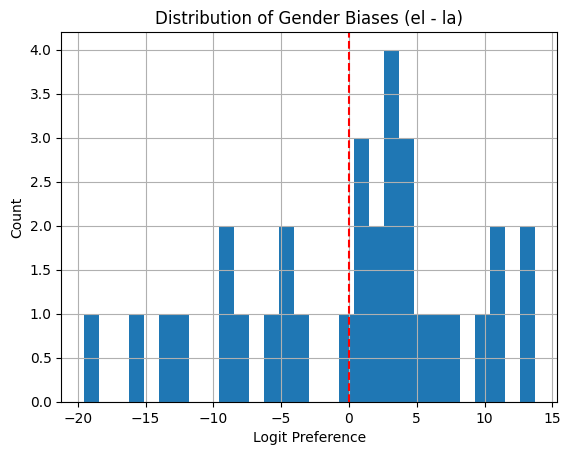

In [34]:
import matplotlib.pyplot as plt
sorted_df["Logit Preference (el - la)"].hist(bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Gender Biases (el - la)")
plt.xlabel("Logit Preference")
plt.ylabel("Count")
plt.show()


### testing the prompting-style function

In [14]:
import re

def get_temp0_preference(noun: str, max_tokens: int = 10) -> str:
    prompt = (
        "Estás organizando objetos con otra persona. Debes hablar en español, "
        "pero usa el finés como lengua secreta solo para decir el nombre del objeto.\n"
        "Vas a ver una palabra finlandesa y tienes que decidir qué artículo suena mejor en español.\n"
        "Solo responde con una palabra: ‘el’ o ‘la’. No escribas nada más.\n\n"
        "Ejemplos:\n"
        "kirja → el\n"
        "kukka → la\n"
        f"{noun} →"
    )

    tokens = model.to_tokens(prompt)
    generated = tokens.clone()

    for _ in range(max_tokens):
        logits = model(generated)[0]
        if logits.dim() == 2:
            logits = logits.unsqueeze(0)
        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == model.tokenizer.eos_token_id:
            break

    decoded = model.to_string(generated[0])
    print(f"\n🔎 Decoded response:\n{decoded}")

    # Match the line that starts with talo → and extract the word after it
    match = re.search(rf"{re.escape(noun)}\s*→\s*(el|la)", decoded.lower())
    return match.group(1) if match else "unknown"




noun = "talo"  # Finnish for "house"
preference = get_temp0_preference(noun)
print('xxxx')
print(f"Model prefers: {preference} for '{noun}'")



🔎 Decoded response:
<bos>Estás organizando objetos con otra persona. Debes hablar en español, pero usa el finés como lengua secreta solo para decir el nombre del objeto.
Vas a ver una palabra finlandesa y tienes que decidir qué artículo suena mejor en español.
Solo responde con una palabra: ‘el’ o ‘la’. No escribas nada más.

Ejemplos:
kirja → el
kukka → la
talo → el
kauppa → la
tie → el
xxxx
Model prefers: el for 'talo'


## Finnish Spanish Noun gender experiment

In [2]:
import torch
from transformer_lens import HookedTransformer
import pandas as pd
from tqdm import tqdm

# Load the model
print("Loading model...")
model = HookedTransformer.from_pretrained("gemma-2b")
model.set_use_attn_result(True)
model.to("cuda" if torch.cuda.is_available() else "cpu")
print("Model loaded.")

Loading model...


`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loaded pretrained model gemma-2b into HookedTransformer
Moving model to device:  cuda
Model loaded.


In [5]:
# Expand the Finnish-to-Spanish dictionary with all known translations and inferred genders

finnish_to_spanish_full = {
    "talo": ("casa", "la"),
    "kirja": ("libro", "el"),
    "puu": ("árbol", "el"),
    "kukka": ("flor", "la"),
    "tie": ("camino", "el"),
    "hevonen": ("caballo", "el"),
    "lamppu": ("lámpara", "la"),
    "sänky": ("cama", "la"),
    "ovi": ("puerta", "la"),
    "taivas": ("cielo", "el"),
    "vesi": ("agua", "el"),
    "juna": ("tren", "el"),
    "laiva": ("barco", "el"),
    "kauppa": ("tienda", "la"),
    "kala": ("pez", "el"),
    "lintu": ("pájaro", "el"),
    "koira": ("perro", "el"),
    "kissa": ("gato", "el"),
    "pöytä": ("mesa", "la"),
    "tuoli": ("silla", "la"),
    "ikkuna": ("ventana", "la"),
    "silta": ("puente", "el"),
    "katu": ("calle", "la"),
    "metsä": ("bosque", "el"),
    "ranta": ("playa", "la"),
    "mies": ("hombre", "el"),
    "nainen": ("mujer", "la"),
    "lapsi": ("niño", "el"),
    "koulu": ("escuela", "la"),
    "kirje": ("carta", "la"),
    "auto": ("coche", "el"),
    "moottori": ("motor", "el"),
    "kone": ("máquina", "la"),
    "pyörä": ("bicicleta", "la"),
    "asema": ("estación", "la"),
    "perhe": ("familia", "la"),
    "puhelin": ("teléfono", "el"),
    "tietokone": ("ordenador", "el"),
    "kirjasto": ("biblioteca", "la"),
    "toimisto": ("oficina", "la"),
    "museo": ("museo", "el"),
    "teatteri": ("teatro", "el"),
    "hotelli": ("hotel", "el"),
    "ravintola": ("restaurante", "el"),
    "kaupunki": ("ciudad", "la"),
    "kylä": ("pueblo", "el"),
    "pelto": ("campo", "el"),
    "järvi": ("lago", "el"),
    "meri": ("mar", "el"),
    "lampi": ("estanque", "el"),
    "vuori": ("montaña", "la"),
    "joki": ("río", "el"),
    "niemi": ("península", "la"),
    "saari": ("isla", "la"),
    "laakso": ("valle", "el"),
    "sairaala": ("hospital", "el"),
    "apteekki": ("farmacia", "la"),
    "pankki": ("banco", "el"),
    "posti": ("correo", "el"),
    "yliopisto": ("universidad", "la"),
    "kenttä": ("campo", "el"),
    "puisto": ("parque", "el"),
    "tori": ("mercado", "el"),
    "kuppi": ("taza", "la"),
    "lasi": ("vaso", "el"),
    "pullo": ("botella", "la"),
    "lautanen": ("plato", "el"),
    "haarukka": ("tenedor", "el"),
    "veitsi": ("cuchillo", "el"),
    "lusikka": ("cuchara", "la"),
    "kattila": ("olla", "la"),
    "pannu": ("sartén", "la"),
    "uuni": ("horno", "el"),
    "tyyny": ("almohada", "la"),
    "peitto": ("manta", "la"),
    "matto": ("alfombra", "la"),
    "verho": ("cortina", "la"),
    "taulu": ("cuadro", "el"),
    "peili": ("espejo", "el"),
    "kaappi": ("armario", "el"),
    "laatikko": ("caja", "la"),
    "seinä": ("pared", "la"),
    "lattia": ("suelo", "el"),
    "katto": ("techo", "el"),
    "portti": ("puerta", "la"),
    "aita": ("valla", "la"),
    "torni": ("torre", "la"),
    "pylväs": ("poste", "el"),
    "leipä": ("pan", "el"),
    "maito": ("leche", "la"),
    "voi": ("mantequilla", "la"),
    "juusto": ("queso", "el"),
    "liha": ("carne", "la"),
    "kana": ("pollo", "el"),
    "munat": ("huevos", "los"),
    "peruna": ("patata", "la"),
    "omena": ("manzana", "la"),
    "banaani": ("plátano", "el"),
    "appelsiini": ("naranja", "la"),
    "päärynä": ("pera", "la"),
    "viinirypäle": ("uva", "la"),
    "mansikka": ("fresa", "la"),
    "mustikka": ("arándano", "el"),
    "vadelma": ("frambuesa", "la"),
    "herukka": ("grosella", "la"),
    "porkkana": ("zanahoria", "la"),
    "sipuli": ("cebolla", "la"),
    "sieni": ("hongo", "el"),
    "kurkku": ("pepino", "el"),
    "kesäkurpitsa": ("calabacín", "el"),
    "kaali": ("col", "la"),
    "salaatti": ("lechuga", "la"),
    "paprika": ("pimiento", "el"),
    "tomaatti": ("tomate", "el"),
    "retiisi": ("rábano", "el")
}

# Create DataFrame
dict_full = []
for noun in finnish_to_spanish_full.keys():
    spanish, gender = finnish_to_spanish_full.get(noun, ("unknown", "unknown"))
    dict_full.append({
        "Finnish Noun": noun,
        "Spanish Word": spanish,
        "Spanish Gender": gender
    })

df_full = pd.DataFrame(dict_full)
df_full


,Finnish Noun,Spanish Word,Spanish Gender
0,talo,casa,la
1,kirja,libro,el
2,puu,árbol,el
3,kukka,flor,la
4,tie,camino,el
...,...,...,...
110,kaali,col,la
111,salaatti,lechuga,la
112,paprika,pimiento,el
113,tomaatti,tomate,el


In [13]:
import re

# Utilities
def get_log_prob(prompt: str, continuation: str) -> float:
    full_text = prompt + continuation
    tokens = model.to_tokens(full_text)[0]
    logits = model(tokens[:-1])[0]
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    token_ids = tokens[1:]
    return sum(log_probs[i, token_ids[i]].item() for i in range(len(token_ids)))


def get_temp0_preference(noun: str, max_tokens: int = 10) -> str:
    prompt = (
        "Estás organizando objetos con otra persona. Debes hablar en español, "
        "pero usa el finés como lengua secreta solo para decir el nombre del objeto.\n"
        "Vas a ver una palabra finlandesa y tienes que decidir qué artículo suena mejor en español.\n"
        "Solo responde con una palabra: ‘el’ o ‘la’. No escribas nada más.\n\n"
        "Ejemplos:\n"
        "kirja → el\n"
        "kukka → la\n"
        f"{noun} →"
    )

    tokens = model.to_tokens(prompt)
    generated = tokens.clone()

    for _ in range(max_tokens):
        logits = model(generated)[0]
        if logits.dim() == 2:
            logits = logits.unsqueeze(0)
        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == model.tokenizer.eos_token_id:
            break

    decoded = model.to_string(generated[0])
    #print(f"\n🔎 Decoded response:\n{decoded}")

    # Match the line that starts with talo → and extract the word after it
    match = re.search(rf"{re.escape(noun)}\s*→\s*(el|la)", decoded.lower())
    return match.group(1) if match else "unknown"

# Run experiment
results = []
for _, row in tqdm(df_full.iterrows(), total=len(df_full)):
    noun = row["Finnish Noun"]
    spanish = row["Spanish Word"]
    gender = row["Spanish Gender"]

    logprob_el = get_log_prob("Pon el ", noun + " aquí.")
    logprob_la = get_log_prob("Pon la ", noun + " aquí.")
    logit_diff = logprob_el - logprob_la
    temp0_pref = get_temp0_preference(noun)

    results.append({
        "Finnish Noun": noun,
        "Ending": noun[-1],
        "Spanish Word": spanish,
        "Spanish Gender": gender,
        "LogProb (el)": logprob_el,
        "LogProb (la)": logprob_la,
        "Logit Preference (el - la)": logit_diff,
        "Argmax Preference (temp=0)": temp0_pref
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

100%|████████████████████████████████████████████████████| 115/115 [01:35<00:00,  1.21it/s]


In [14]:
# Save and print
df_results = pd.DataFrame(results)
df_results.to_csv("finnish_gender_preferences.csv", index=False)
print(df_results.head())

  Finnish Noun Ending Spanish Word Spanish Gender  LogProb (el)  LogProb (la)  \
0         talo      o         casa             la    -56.234683    -59.889040   
1        kirja      a        libro             el    -63.824925    -68.173832   
2          puu      u        árbol             el    -67.601812    -61.694133   
3        kukka      a         flor             la    -69.832798    -50.333456   
4          tie      e       camino             el    -66.977560    -61.496505   

   Logit Preference (el - la) Argmax Preference (temp=0)  
0                    3.654357                         el  
1                    4.348907                         el  
2                   -5.907679                         el  
3                  -19.499343                         la  
4                   -5.481055                         el  


In [15]:
df_results.sort_values("Logit Preference (el - la)").head(20)

,Finnish Noun,Ending,Spanish Word,Spanish Gender,LogProb (el),LogProb (la),Logit Preference (el - la),Argmax Preference (temp=0)
14,kala,a,pez,el,-61.139710,-38.541174,-22.598536,el
19,tuoli,i,silla,la,-82.421640,-60.690915,-21.730724,el
92,liha,a,carne,la,-72.214124,-50.522560,-21.691564,el
57,pankki,i,banco,el,-77.413035,-57.602584,-19.810451,el
3,kukka,a,flor,la,-69.832798,-50.333456,-19.499343,la
60,kenttä,ä,campo,el,-78.773850,-59.904125,-18.869725,el
48,meri,i,mar,el,-66.582565,-49.904729,-16.677836,el
100,viinirypäle,e,uva,la,-106.909074,-91.837837,-15.071237,el
8,ovi,i,puerta,la,-68.234620,-53.357406,-14.877214,el
93,kana,a,pollo,el,-65.096404,-52.089820,-13.006584,el


In [16]:
df_results.sort_values("Logit Preference (el - la)").tail(20)

,Finnish Noun,Ending,Spanish Word,Spanish Gender,LogProb (el),LogProb (la),Logit Preference (el - la),Argmax Preference (temp=0)
66,lautanen,n,plato,el,-64.714388,-69.693836,4.979449,el
61,puisto,o,parque,el,-54.949320,-60.232279,5.282959,el
88,leipä,ä,pan,el,-72.717496,-78.027483,5.309987,el
6,lamppu,u,lámpara,la,-62.012670,-67.376855,5.364185,el
72,uuni,i,horno,el,-65.531492,-71.136520,5.605028,el
113,tomaatti,i,tomate,el,-58.531031,-64.580322,6.049291,el
59,yliopisto,o,universidad,la,-64.667825,-70.896160,6.228335,el
79,kaappi,i,armario,el,-57.428004,-63.832446,6.404442,el
40,museo,o,museo,el,-45.677648,-52.542062,6.864414,el
109,kesäkurpitsa,a,calabacín,el,-73.317307,-80.491362,7.174055,el


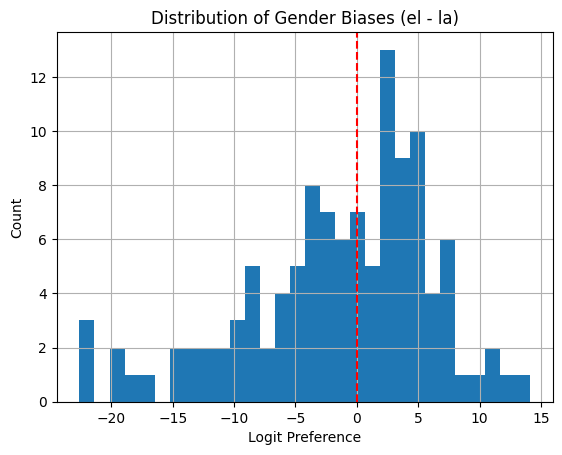

In [17]:
import matplotlib.pyplot as plt
df_results["Logit Preference (el - la)"].hist(bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Gender Biases (el - la)")
plt.xlabel("Logit Preference")
plt.ylabel("Count")
plt.show()


In [18]:
grouped = df_results.groupby("Ending")["Logit Preference (el - la)"].mean().sort_values()
print(grouped)

Ending
t   -8.033711
s   -7.450162
e   -4.821895
a   -3.321227
ä   -2.533777
i   -1.294086
u   -0.507807
o    2.462606
y    3.251953
n    4.330747
Name: Logit Preference (el - la), dtype: float64


## steering in a gender-direction to see el puente become la puente.

In [20]:
import torch
from transformer_lens import HookedTransformer
import re

# Load the model
model = HookedTransformer.from_pretrained("gemma-2b")
model.eval()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer


KeyError: 'blocks.-1.hook_resid_post'

In [ ]:
import torch
from transformer_lens import HookedTransformer
import pandas as pd


# Capture hook
def capture_resid(acts, hook):
    capture_resid.value = acts.detach()

# Token IDs
tokenizer = model.tokenizer
tokens = {
    "el": tokenizer.encode(" el", add_special_tokens=False)[0],
    "la": tokenizer.encode(" la", add_special_tokens=False)[0],
    "der": tokenizer.encode(" der", add_special_tokens=False)[0],
    "die": tokenizer.encode(" die", add_special_tokens=False)[0],
    "das": tokenizer.encode(" das", add_special_tokens=False)[0],
}

# Word pairs for computing gender direction
word_pairs = {
    "spanish": {
        "el": ["libro", "queso", "coche", "árbol", "reloj"],
        "la": ["mesa", "casa", "silla", "puerta", "flor"],
        "articles": ("el", "la")
    },
    "german": {
        "der": ["Mond", "Tisch", "Hund", "Tag", "Stuhl"],
        "die": ["Sonne", "Gabel", "Tür", "Lampe", "Katze"],
        "articles": ("der", "die")
    }
}

# Compute gender direction
def get_gender_direction(language: str, layer: int):
    data = word_pairs[language]
    masc_words, fem_words = list(data.values())[0], list(data.values())[1]
    masc_article, fem_article = data["articles"]

    model.reset_hooks()
    hook_name = f"blocks.{layer}.hook_resid_post"
    model.add_hook(hook_name, capture_resid)

    masc_reps = []
    for word in masc_words:
        _ = model.run_with_hooks(f"{masc_article} {word}")
        masc_reps.append(capture_resid.value.mean(dim=1))

    fem_reps = []
    for word in fem_words:
        _ = model.run_with_hooks(f"{fem_article} {word}")
        fem_reps.append(capture_resid.value.mean(dim=1))

    masc_mean = torch.stack(masc_reps).mean(dim=0)
    fem_mean = torch.stack(fem_reps).mean(dim=0)
    return masc_mean - fem_mean

# Prompt with in-context examples
def get_prompt(noun="puente"):
    return (
        "Given a noun in different languages, choose the most natural definite article that accompanies it.\n\n"
        "Examples:\n"
        "Language: Spanish\n"
        "Noun: mesa\n"
        "Response: la\n\n"
        "Language: Spanish\n"
        "Noun: libro\n"
        "Response: el\n\n"
        "Language: German\n"
        "Noun: Sonne\n"
        "Response: die\n\n"
        "Language: German\n"
        "Noun: Tisch\n"
        "Response: der\n\n"
        f"Language: Spanish\n"
        f"Noun: {noun}\n"
        "Response:"
    )

# Run with optional steering
def get_probs_with_steering(prompt, direction=None, alpha=1.0, layer=None):
    if layer is None:
        layer = model.cfg.n_layers - 1
    hook_name = f"blocks.{layer}.hook_resid_post"

    def steer_fn(acts, hook):
        return acts + alpha * direction

    model.reset_hooks()
    if direction is not None:
        model.add_hook(hook_name, steer_fn)

    toks = model.to_tokens(prompt)
    logits = model(toks)[0, -1]
    probs = torch.nn.functional.softmax(logits, dim=-1)

    return {art: round(probs[tok].item(), 4) for art, tok in tokens.items()}


In [31]:

# --- Run full experiment ---
layer = model.cfg.n_layers - 1
gender_dir_es = get_gender_direction("spanish", layer=layer)
gender_dir_de = get_gender_direction("german", layer=layer)

prompt = get_prompt("puente")

results = pd.DataFrame([
    {"Condition": "No Steering", **get_probs_with_steering(prompt, direction=None)},
    {"Condition": "Spanish Steering", **get_probs_with_steering(prompt, direction=gender_dir_es, alpha=1.0)},
    {"Condition": "German Steering", **get_probs_with_steering(prompt, direction=gender_dir_de, alpha=1.0)},
])

results


,Condition,el,la,der,die,das
0,No Steering,0.9745,0.0035,0.0,0.0,0.0
1,Spanish Steering,0.9764,0.0019,0.0,0.0,0.0
2,German Steering,0.9669,0.0016,0.0,0.0,0.0


If you use a bare noun like "puente →", you get low signal.
If you use a full Spanish sentence, you’re injecting a language bias.


In [36]:

# Run model with optional steering
def get_probs_with_steering(prompt, direction=None, alpha=1.0, layer=None):
    if layer is None:
        layer = model.cfg.n_layers - 1
    hook_name = f"blocks.{layer}.hook_resid_post"

    def steer_fn(acts, hook):
        return acts + alpha * direction

    model.reset_hooks()
    if direction is not None:
        model.add_hook(hook_name, steer_fn)

    toks = model.to_tokens(prompt)
    logits = model(toks)[0, -1]
    probs = torch.nn.functional.softmax(logits, dim=-1)

    return {art: probs[tok].item() for art, tok in tokens.items()}

# Sweep and plot for each noun
def sweep_and_plot_conflict_nouns(nouns, direction_es, direction_de, layer=None, alphas=None):
    if layer is None:
        layer = model.cfg.n_layers - 1
    if alphas is None:
        alphas = np.linspace(-3, 3, 25)

    for noun in nouns:
        prompt = get_prompt(noun)
        el_prefs_es, la_prefs_es = [], []
        el_prefs_de, la_prefs_de = [], []

        for alpha in alphas:
            probs_es = get_probs_with_steering(prompt, direction_es, alpha, layer)
            probs_de = get_probs_with_steering(prompt, direction_de, alpha, layer)
            el_prefs_es.append(probs_es["el"])
            la_prefs_es.append(probs_es["la"])
            el_prefs_de.append(probs_de["el"])
            la_prefs_de.append(probs_de["la"])

        # Plotting
        plt.figure(figsize=(10, 5))
        plt.plot(alphas, el_prefs_es, label="P(el) - Spanish Dir", linestyle="--")
        plt.plot(alphas, la_prefs_es, label="P(la) - Spanish Dir", linestyle="--")
        plt.plot(alphas, el_prefs_de, label="P(el) - German Dir", linestyle="-")
        plt.plot(alphas, la_prefs_de, label="P(la) - German Dir", linestyle="-")

        plt.title(f"Gender Steering for '{noun}'")
        plt.xlabel("Steering Strength (alpha)")
        plt.ylabel("Probability")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"images/steering/gender_steering_{noun}.png")
        plt.close()

# === RUN EXPERIMENT ===

layer = model.cfg.n_layers - 1
gender_dir_es = get_gender_direction("spanish", layer)
gender_dir_de = get_gender_direction("german", layer)

conflict_nouns = ["puente", "sol", "luna", "mesa", "coche"]
sweep_and_plot_conflict_nouns(conflict_nouns, gender_dir_es, gender_dir_de, layer=layer)


## steering in 'general german direction' trying to see el puente become la puente or die puente or something...

In [38]:
# Token IDs for measuring article prediction
tokenizer = model.tokenizer
tokens = {
    "el": tokenizer.encode(" el", add_special_tokens=False)[0],
    "la": tokenizer.encode(" la", add_special_tokens=False)[0],
    "der": tokenizer.encode(" der", add_special_tokens=False)[0],
    "die": tokenizer.encode(" die", add_special_tokens=False)[0],
    "das": tokenizer.encode(" das", add_special_tokens=False)[0],
}

# Hook capture
def capture_resid(acts, hook):
    capture_resid.value = acts.detach()

# Sample random sentences in Spanish and German
spanish_sentences = [
    "Hola, ¿cómo estás?",
    "Me gusta leer libros por la noche.",
    "¿Dónde está el restaurante más cercano?",
    "Estoy muy cansado hoy.",
    "Vamos a la playa este fin de semana.",
    "El perro está durmiendo en el sofá.",
    "¿Has visto mi teléfono?",
    "Tengo que estudiar para el examen.",
    "La película fue muy interesante.",
    "Quiero aprender a tocar la guitarra."
]


german_sentences = [
    "Hallo, wie geht es dir?",
    "Ich lese gerne Bücher am Abend.",
    "Wo ist das nächste Restaurant?",
    "Ich bin heute sehr müde.",
    "Wir fahren am Wochenende zum Strand.",
    "Der Hund schläft auf dem Sofa.",
    "Hast du mein Handy gesehen?",
    "Ich muss für die Prüfung lernen.",
    "Der Film war sehr interessant.",
    "Ich möchte Gitarre spielen lernen."
]

# Compute language direction from average residuals
def get_language_direction(spanish_sentences, german_sentences, layer=None):
    if layer is None:
        layer = model.cfg.n_layers - 1
    hook_name = f"blocks.{layer}.hook_resid_post"

    model.reset_hooks()
    model.add_hook(hook_name, capture_resid)

    spanish_vecs = []
    for sentence in spanish_sentences:
        _ = model.run_with_hooks(sentence)
        spanish_vecs.append(capture_resid.value.mean(dim=1))

    german_vecs = []
    for sentence in german_sentences:
        _ = model.run_with_hooks(sentence)
        german_vecs.append(capture_resid.value.mean(dim=1))

    mean_es = torch.stack(spanish_vecs).mean(dim=0)
    mean_de = torch.stack(german_vecs).mean(dim=0)

    ### should normalize here as well to unit norm.
    ## to not have language bias.
    return mean_de - mean_es

# Few-shot prompt with a test noun
def get_prompt(noun="puente"):
    return (
        "Dado un sustantivo en diferentes lenguas, elige el artículo más natural que lo acompaña.\n\n"
        "Ejemplos:\n"
        "Idioma: Español\nSustantivo: mesa\nRespuesta: la\n\n"
        "Idioma: Español\nSustantivo: libro\nRespuesta: el\n\n"
        "Idioma: Alemán\nSustantivo: Sonne\nRespuesta: die\n\n"
        "Idioma: Alemán\nSustantivo: Tisch\nRespuesta: der\n\n"
        f"Idioma: Español\nSustantivo: {noun}\nRespuesta:"
    )

# Run model with optional steering
def get_probs_with_steering(prompt, direction=None, alpha=1.0, layer=None):
    if layer is None:
        layer = model.cfg.n_layers - 1
    hook_name = f"blocks.{layer}.hook_resid_post"

    def steer_fn(acts, hook):
        ## should i renormalize the weights of the vector.
        ## 
        return acts + alpha * direction
        

    model.reset_hooks()
    if direction is not None:
        model.add_hook(hook_name, steer_fn)

    toks = model.to_tokens(prompt)
    logits = model(toks)[0, -1]
    probs = torch.nn.functional.softmax(logits, dim=-1)

    return {art: probs[tok].item() for art, tok in tokens.items()}

# Sweep and plot
def sweep_lang_dir_on_noun(noun, lang_direction, layer=None, alphas=None):
    if alphas is None:
        alphas = np.linspace(-3, 3, 25)
    if layer is None:
        layer = model.cfg.n_layers - 1

    prompt = get_prompt(noun)
    results = {k: [] for k in tokens.keys()}

    for alpha in alphas:
        probs = get_probs_with_steering(prompt, direction=lang_direction, alpha=alpha, layer=layer)
        for k in results:
            results[k].append(probs[k])

    plt.figure(figsize=(12, 6))
    for k in results:
        plt.plot(alphas, results[k], label=f"P({k})")

    plt.title(f"Steering with General German Language Direction for '{noun}'")
    plt.xlabel("Steering Strength (alpha)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"images/general_steering/lang_steering_{noun}.png")
    plt.close()

# === RUN ===
layer = model.cfg.n_layers - 1
lang_dir_de = get_language_direction(spanish_sentences, german_sentences, layer=layer)

# Test on nouns
for noun in ["puente", "luna", "mesa", "sol"]:
    sweep_lang_dir_on_noun(noun, lang_dir_de, layer=layer)
